In [1]:
import os
import sys
from concurrent.futures import ThreadPoolExecutor, as_completed

sys.path.append('/home/agustin/phd/synthesis')
sys.path.append('/home/agustin/phd/miccai/miccai_2026/mri_x_fields/experiments/utils')

import utils.nifti_functions as nfc
import utils.functions as fc
import utils.util as util
import utils.util_freesurfer_segmentation as ufs

import numpy as np
import pandas as pd
from tqdm import tqdm
import torch

from autoencoder_declaration import AutoencoderPrediction
import prep_image as prep_image


device_name = "cuda:2"
device = torch.device(device_name)
from PIL import Image



### For the first model Normalyse by WM and use 1.5 T

In [2]:
autoencoder_chk_path = "/home/agustin/phd/BrainST/models/autoencoder/weights/autoencoder_epoch273.pt"
half = True
autoencoder = AutoencoderPrediction(autoencoder_chk_path, device, half=half)
    
latent = np.load("/home/agustin/phd/miccai/miccai_2026/mri_x_fields/data/pr_train_data/preprocessed/maisi_latents_normalized_wm/T1W/5.0T/SP_T1W_5T_0006_latent.npy")
img = autoencoder.decode(latent, decode_complete=False)


100%|██████████| 27/27 [00:23<00:00,  1.14it/s]


In [4]:
img_created = img.squeeze().cpu().numpy()

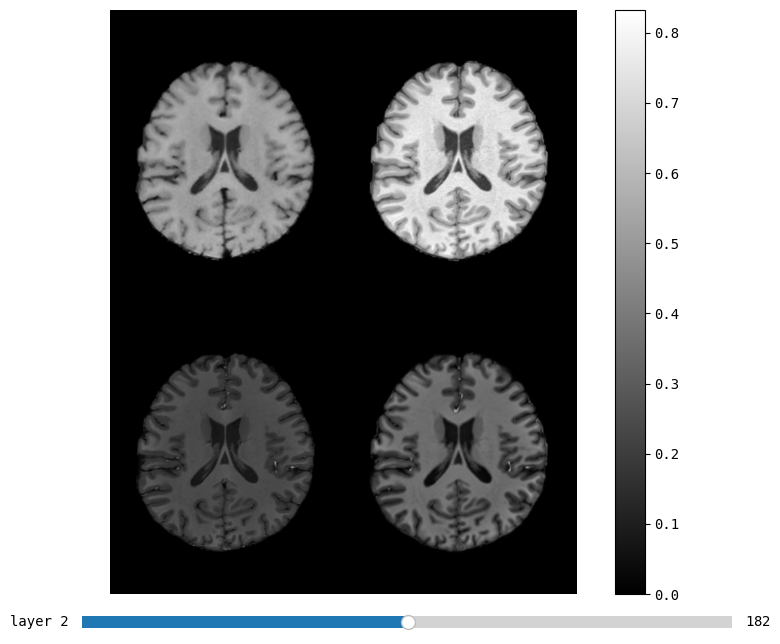

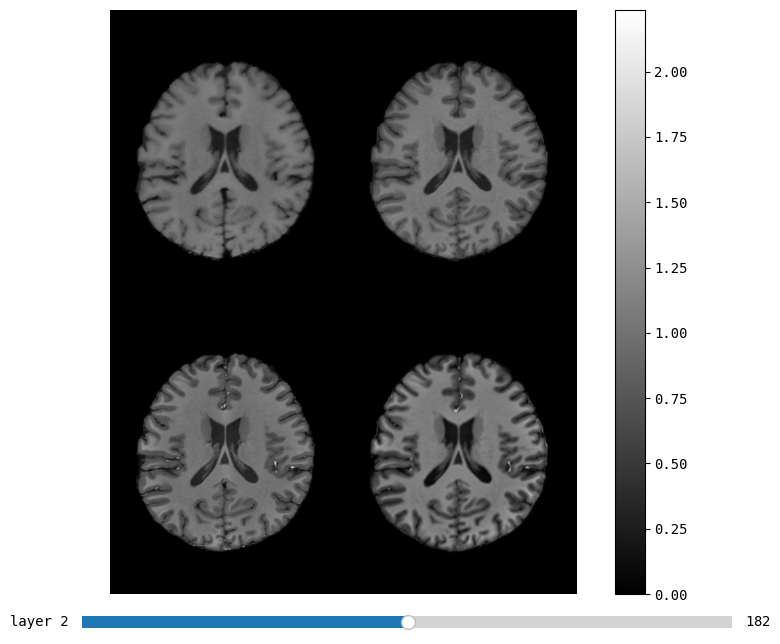

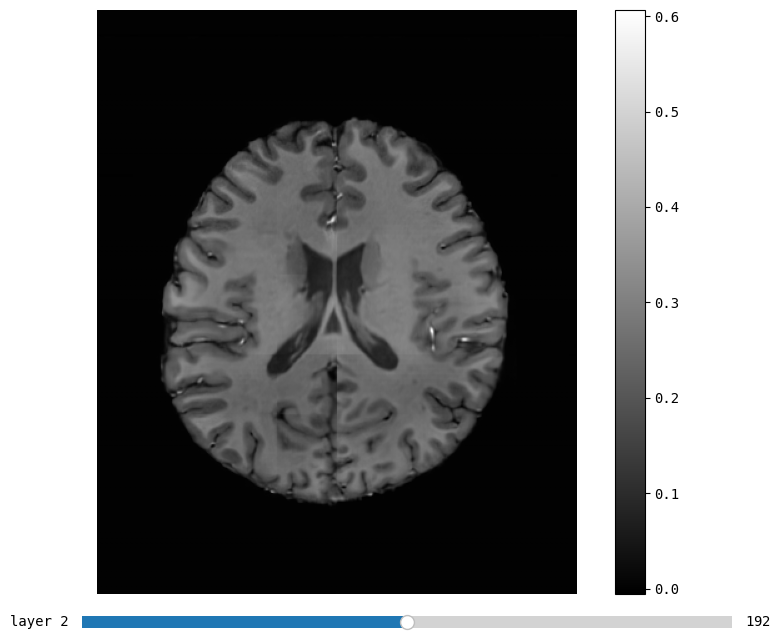

In [7]:
imgs = []
imgs_norm = []
loaded_res = []
df = pd.read_csv('/home/agustin/phd/miccai/miccai_2026/mri_x_fields/data/csv/pr_train_data.csv')
modality = 'T1W' # can be T1W, T2W or T2FLAIR
resolutions = [1.5,3,5,7]
# find subject ids that end by 0006
df = df[df['subject_id'].str.endswith('0006')]
df = df[df['modality'] == modality]
df = df[df['resolution'].isin(resolutions)]

def normalize_image_by_cerebral_wm_mean(img, wm_mask):
    # cerebral_wm_mask = ufs.merge_seg96_to_mask(seg, [ufs.CEREBRAL_WM])
    mean_value = img[wm_mask == 1].mean()
    img_normalized = img / mean_value
    return img_normalized


for i, row in df.iterrows():
    s_id = row['subject_id']
    modality = row['modality']
    resolution = row['resolution']
    img_path = row['path']
    seg_path = row['segmentation_path']
    loaded_res.append(str(resolution))
    
    img, aff = nfc.load_nifti(img_path, transpose=False)
    seg, aff = nfc.load_nifti(seg_path, transpose=False)

    wm_mask = ufs.merge_seg96_to_mask(seg, [ufs.CEREBRAL_WM])
    img_normalized = normalize_image_by_cerebral_wm_mean(img, wm_mask)
    imgs.append(img)
    imgs_norm.append(img_normalized)
    

fc.imgshow_3D_list(imgs)
fc.imgshow_3D_list(imgs_norm)
fc.imgshow_3D_list([img_created])
# fc.imgshow_3D_list(imgs, subimg_titles=loaded_res)